## Set up working environment

Make sure the repo_root is added correctly, it should be: ```your_root_dir/dod2k```
This should be the working directory throughout this notebook (and all other notebooks).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
from pathlib import Path

# Add parent directory to path (works from any notebook in notebooks/)
# the repo_root should be the parent directory of the notebooks folder
init_dir = Path().resolve()
# Determine repo root
if init_dir.name == 'dod2k': repo_root = init_dir
elif init_dir.parent.name == 'dod2k': repo_root = init_dir.parent
else: raise Exception('Please review the repo root structure (see first cell).')

# Update cwd and path only if needed
if os.getcwd() != str(repo_root):
    os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f"Repo root: {repo_root}")
if str(os.getcwd())==str(repo_root):
    print(f"Working directory matches repo root. ")

Repo root: /home/skidush/PaleoCoLab/dod2k
Working directory matches repo root. 


In [2]:
# Import packages
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import xarray as xr
import rioxarray
from tqdm import tqdm
import psm
import statsmodels.api as sm
import scipy

from dod2k_utilities import ut_functions as utf # contains utility functions
from dod2k_utilities import ut_plot as uplt # contains plotting functions
from dod2k_utilities import ut_analysis as uta # contains plotting functions

## Read dataframe

Read compact dataframe.

{db_name} refers to the database, including 

    - dod2k_v2.0
    
All compact dataframes are saved in {repo_root}/data/{db_name} as {db_name}_compact.csv.

In [3]:
# read dataframe, choose from the list below, or specify your own

db_name = 'dod2k_v2.0'

# load dataframe
orig_df = utf.load_compact_dataframe_from_csv(db_name)
print(orig_df.info())
orig_df.name = db_name
orig_df["archiveType"].unique()


<class 'pandas.DataFrame'>
RangeIndex: 4781 entries, 0 to 4780
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   archiveType                    4781 non-null   str    
 1   dataSetName                    4781 non-null   str    
 2   datasetId                      4781 non-null   str    
 3   duplicateDetails               4781 non-null   str    
 4   geo_meanElev                   4699 non-null   float32
 5   geo_meanLat                    4781 non-null   float32
 6   geo_meanLon                    4781 non-null   float32
 7   geo_siteName                   4781 non-null   str    
 8   interpretation_direction       4781 non-null   str    
 9   interpretation_seasonality     4781 non-null   str    
 10  interpretation_variable        4781 non-null   str    
 11  interpretation_variableDetail  4781 non-null   str    
 12  originalDataURL                4781 non-null   str    
 13 

<StringArray>
[          'Wood',          'Coral',   'LakeSediment', 'MarineSediment',
      'Documents',     'GlacierIce',       'Borehole',   'Sclerosponge',
     'Speleothem',     'Multiproxy',      'GroundIce',   'MolluskShell']
Length: 12, dtype: str

## Filter dataframe for glacier ice core type records

In [4]:
# Filter for desired data, in this case, speleothem calcite oxygen isotope measurements from the years min_year to max_year
filtered_df = orig_df.loc[orig_df["archiveType"] == "Wood"]

# Filter data for time series that include records from or past the year 1960 AD
min_year = 1840 # Inclusive
max_year = 2025 # Exclusive

# d18O data ranges from 1960 to 2005- pick data to match the same timeframe
filtered_df = filtered_df.loc[orig_df["year"].apply(lambda x: np.max(x) >= min_year and np.min(x) < max_year and np.max(x) >= max_year - 50 and np.min(x) <= min_year + 50)] #exclude post 2005 data
filtered_df.reset_index(inplace = True)

# Filter the filtered records for data in the correct timeframe
new_year = []
new_values = []
# For every row, apply above time conditions
for i in range (0, len(filtered_df)):
    index = np.where(filtered_df.iloc[i]["year"] >= min_year)
    new_year.append(filtered_df.iloc[i]["year"][index]) # Adds values to lists
    new_values.append(filtered_df.iloc[i]["paleoData_values"][index])
filtered_df["year"] = new_year # Create a dataframe with the filtered data lists populating it
filtered_df["paleoData_values"] = new_values
filtered_df.info()

filtered_df.name = 'dod2k_v2.0_Wood'

trw_df = filtered_df.loc[filtered_df['paleoData_proxy'] == 'ring width']

print(filtered_df.name)
filtered_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 2901 entries, 0 to 2900
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   index                          2901 non-null   int64  
 1   archiveType                    2901 non-null   str    
 2   dataSetName                    2901 non-null   str    
 3   datasetId                      2901 non-null   str    
 4   duplicateDetails               2901 non-null   str    
 5   geo_meanElev                   2881 non-null   float32
 6   geo_meanLat                    2901 non-null   float32
 7   geo_meanLon                    2901 non-null   float32
 8   geo_siteName                   2901 non-null   str    
 9   interpretation_direction       2901 non-null   str    
 10  interpretation_seasonality     2901 non-null   str    
 11  interpretation_variable        2901 non-null   str    
 12  interpretation_variableDetail  2901 non-null   str    
 13 

,index,archiveType,dataSetName,datasetId,duplicateDetails,geo_meanElev,geo_meanLat,geo_meanLon,geo_siteName,interpretation_direction,...,originalDataURL,originalDatabase,paleoData_notes,paleoData_proxy,paleoData_sensorSpecies,paleoData_units,paleoData_values,paleoData_variableName,year,yearUnits
0,0,Wood,NAm-MtLemon.Briffa.2002,pages2k_5,N/A,2700.0,32.5,-110.800003,Mt. Lemon,None,...,https://www1.ncdc.noaa.gov/pub/data/paleo/page...,PAGES 2k v2.2.0,nan,ring width,PSME,cm,"[0.721, 0.328, 0.329, 0.648, 0.821, 0.561, 0.7...",ring width,"[1840.0, 1841.0, 1842.0, 1843.0, 1844.0, 1845....",CE
1,1,Wood,NAm-MtLemon.Briffa.2002,pages2k_8,N/A,2700.0,32.5,-110.800003,Mt. Lemon,None,...,https://www1.ncdc.noaa.gov/pub/data/paleo/page...,PAGES 2k v2.2.0,nan,ARSTAN,PSME,nan,"[0.925, 0.418, 0.471, 0.908, 1.122, 0.772, 1.0...",ARSTAN,"[1840.0, 1841.0, 1842.0, 1843.0, 1844.0, 1845....",CE
2,2,Wood,NAm-MtLemon.Briffa.2002,pages2k_18,N/A,2700.0,32.5,-110.800003,Mt. Lemon,None,...,https://www1.ncdc.noaa.gov/pub/data/paleo/page...,PAGES 2k v2.2.0,nan,maximum latewood density,PSME,g/cm3,"[0.878, 0.733, 0.754, 0.805, 0.825, 0.844, 0.8...",maximum latewood density,"[1840.0, 1841.0, 1842.0, 1843.0, 1844.0, 1845....",CE
3,3,Wood,NAm-MtLemon.Briffa.2002,pages2k_19,N/A,2700.0,32.5,-110.800003,Mt. Lemon,positive,...,https://www1.ncdc.noaa.gov/pub/data/paleo/page...,PAGES 2k v2.2.0,nan,maximum latewood density,PSME,nan,"[1.071, 0.88, 0.91, 0.981, 0.994, 1.015, 0.996...",maximum latewood density,"[1840.0, 1841.0, 1842.0, 1843.0, 1844.0, 1845....",CE
4,4,Wood,NAm-MtLemon.Briffa.2002,pages2k_21,N/A,2700.0,32.5,-110.800003,Mt. Lemon,None,...,https://www1.ncdc.noaa.gov/pub/data/paleo/page...,PAGES 2k v2.2.0,nan,ARSTAN,PSME,nan,"[1.065, 0.87, 0.928, 0.99, 1.004, 1.021, 0.987...",ARSTAN,"[1840.0, 1841.0, 1842.0, 1843.0, 1844.0, 1845....",CE


In [5]:
#%% check data extraction for proxy_type and archive_type
proxy_types   = filtered_df['paleoData_proxy'].unique()
archive_types = filtered_df['archiveType'].unique()
calcite_types = filtered_df['paleoData_notes'].unique()

print('Proxy type: ', proxy_types)
print('Archive type: ', archive_types)
filtered_df.reset_index(inplace = True)
filtered_df.head()
filtered_df.to_pickle('data/dod2k_v2.0_Wood/dod2k_v2.0_Wood.pkl')
#utf.write_compact_dataframe_to_csv(filtered_df, 'data/dod2k_v2.0_Wood/dod2k_v2.0_Wood_compact_metadata.csv')
trw = filtered_df.loc[filtered_df['paleoData_proxy'] == 'ring width']

Proxy type:  <StringArray>
[              'ring width',                   'ARSTAN',
 'maximum latewood density',              'reflectance',
                     'd18O',     'humidification index']
Length: 6, dtype: str
Archive type:  <StringArray>
['Wood']
Length: 1, dtype: str


### Plot data

saved figure in /home/skidush/PaleoCoLab/dod2k/figs/TRW/geo_TRW.pdf


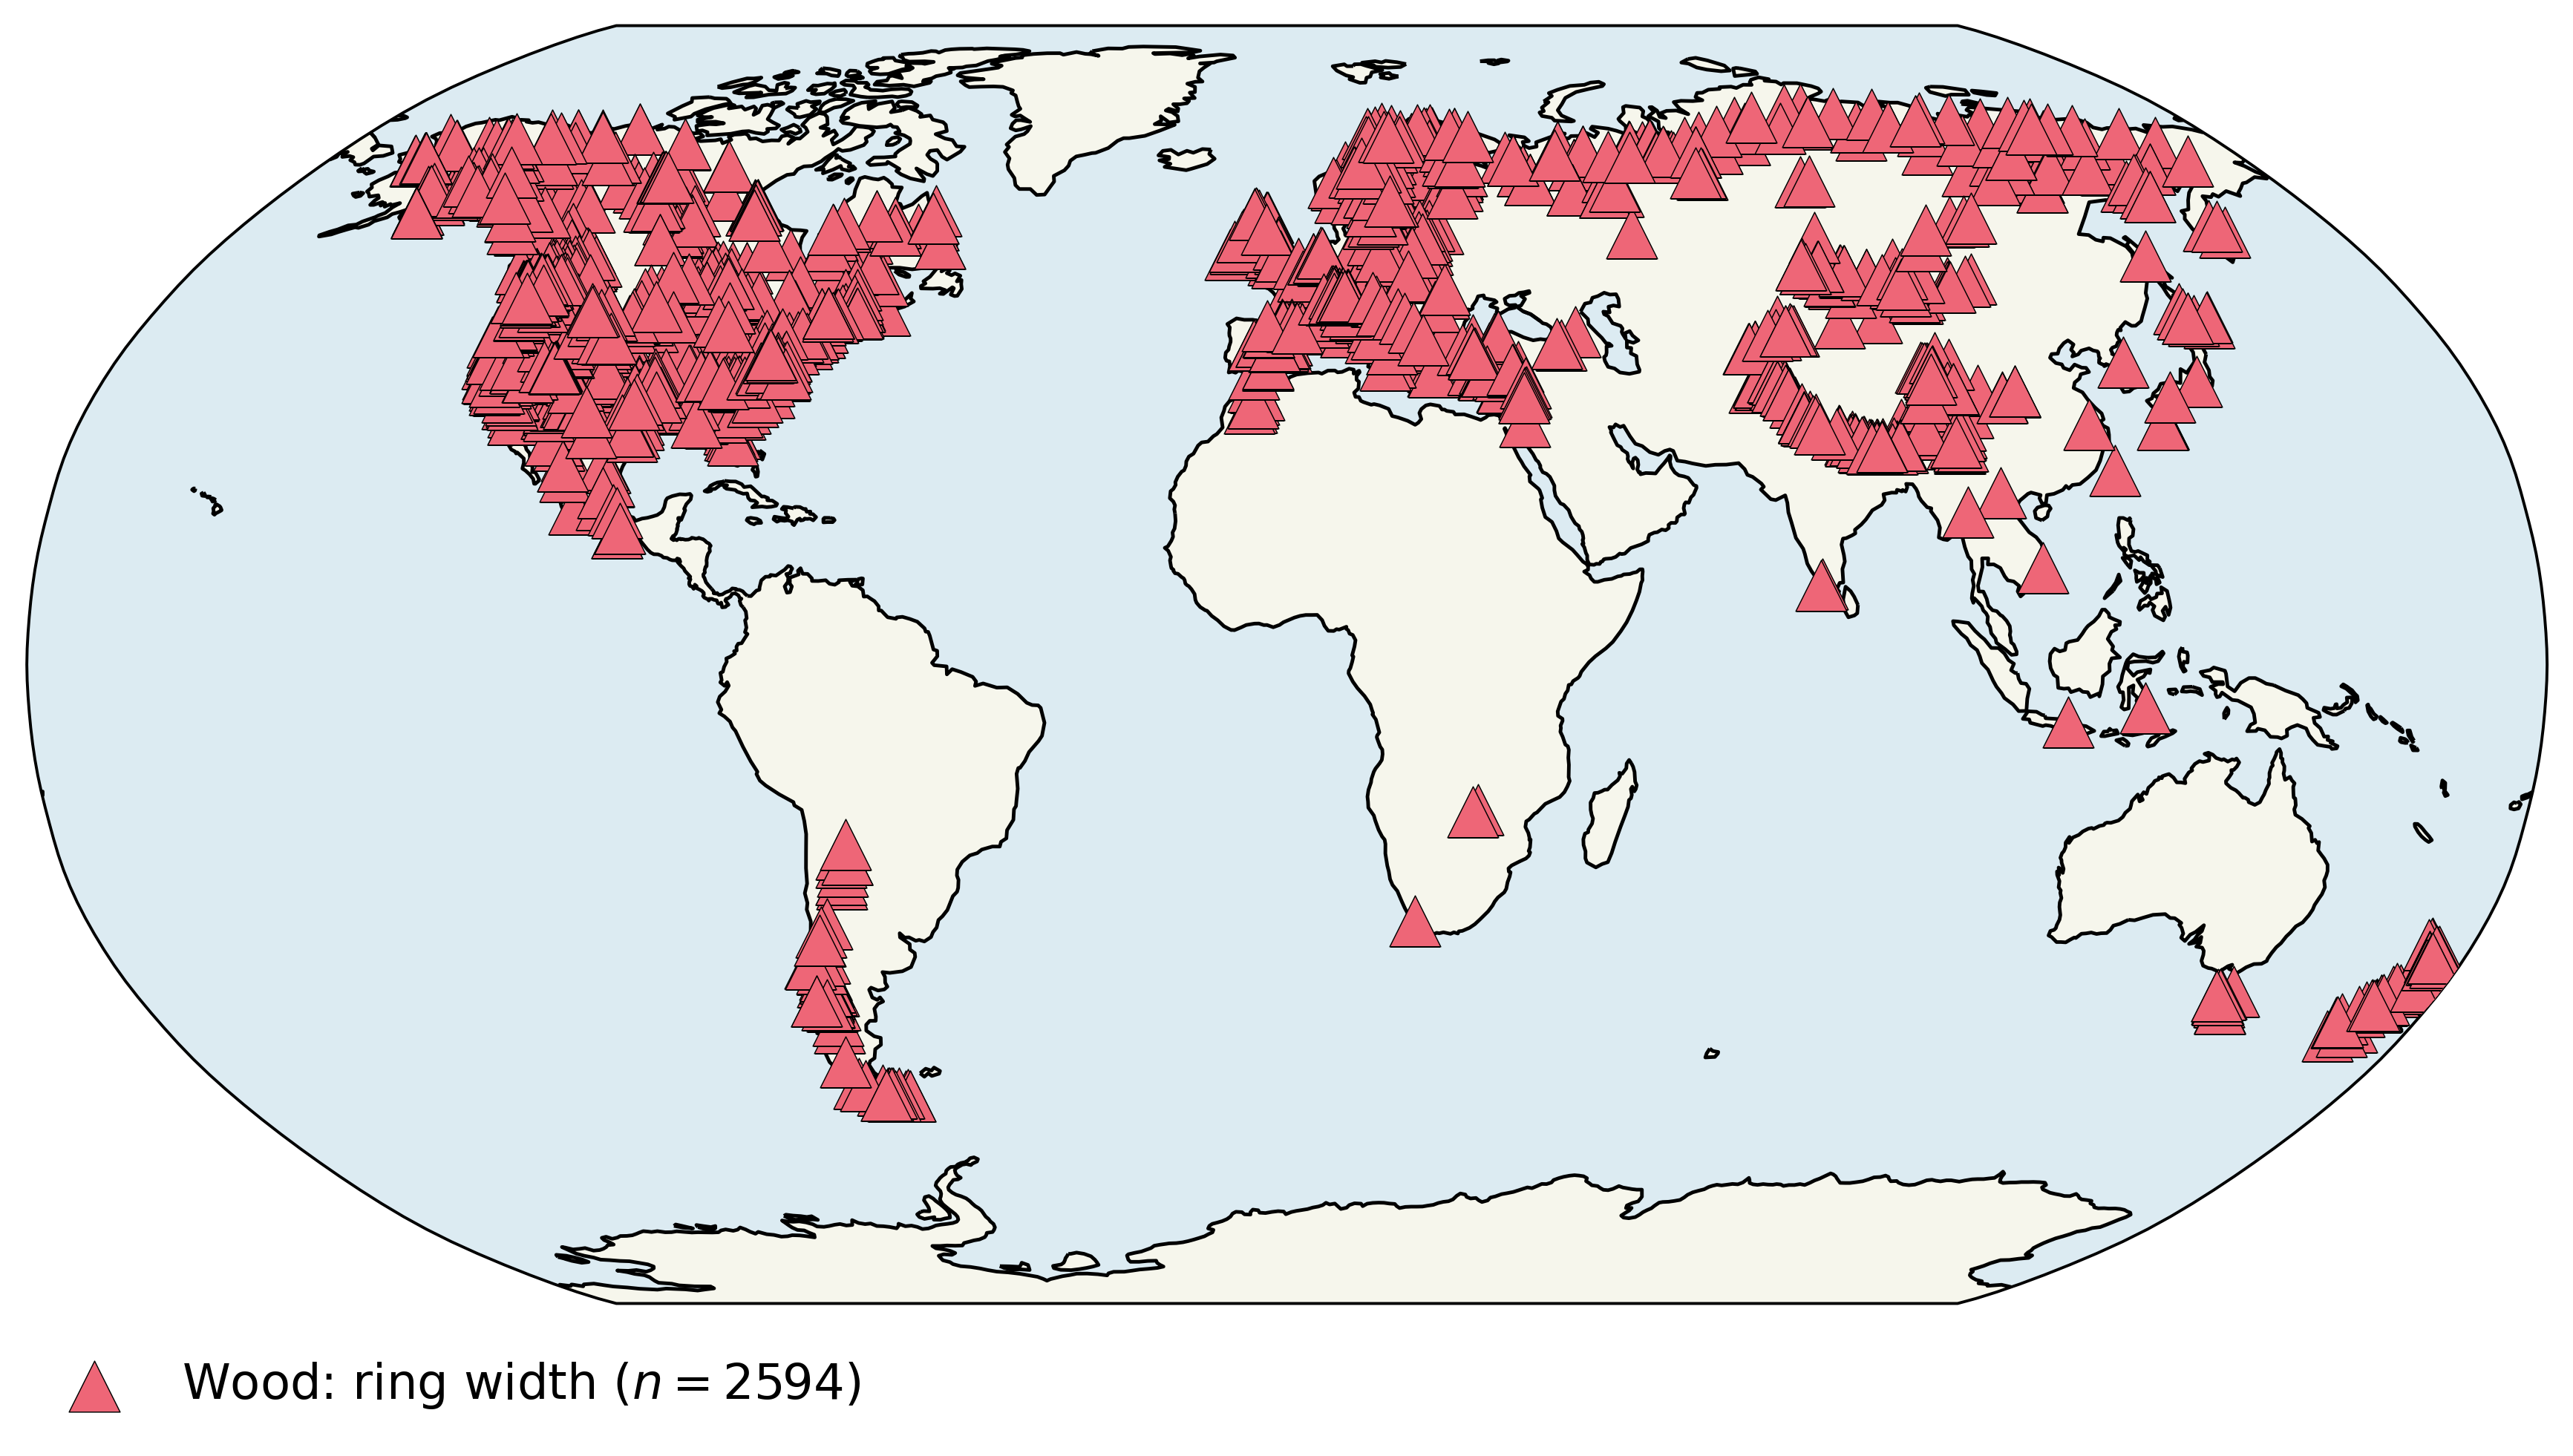

In [6]:
# count archive types
trw_df.name = "TRW"
archive_count = {}
for ii, at in enumerate(set(trw_df['archiveType'])):
    archive_count[at] = trw_df.loc[trw_df['archiveType']==at, 'archiveType'].count()

sort = np.argsort([cc for cc in archive_count.values()])
archives_sorted = np.array([cc for cc in archive_count.keys()])[sort][::-1]

fig = uplt.plot_geo_archive_proxy(trw_df, {'Wood':'#EE6677'}, marker='^', figsize=(13/1.3, 8/1.3))
utf.save_fig(fig, f'geo_{trw_df.name}', dir=trw_df.name)

saved figure in /home/skidush/PaleoCoLab/dod2k/figs/TRW/time_TRW.pdf


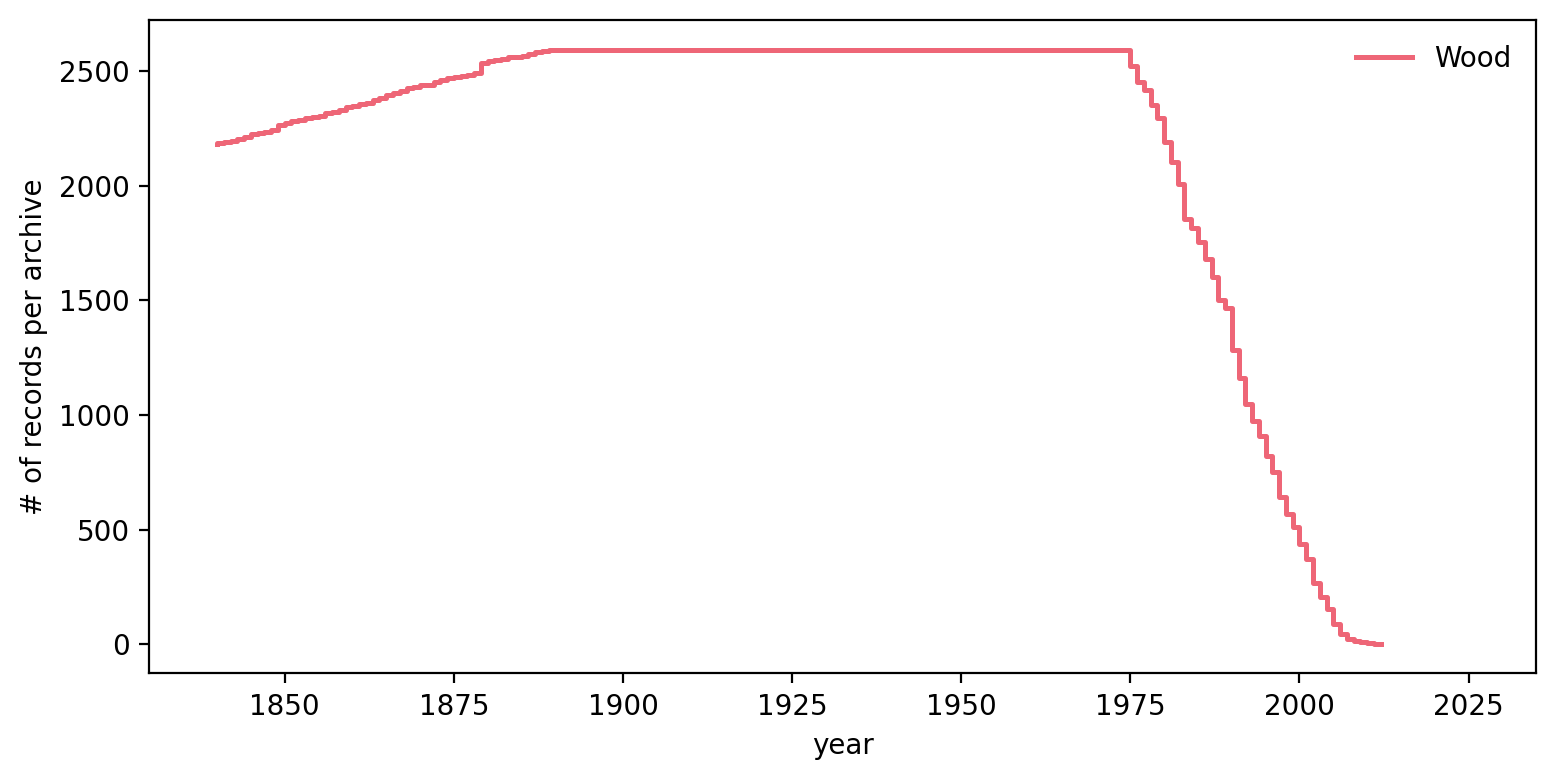

In [7]:
fig = uplt.plot_coverage(trw_df, archives_sorted, ['Wood'], [], {'Wood':'#EE6677'})
plt.xlim(min_year-10, max_year+10)
utf.save_fig(fig, f'time_{trw_df.name}', dir=trw_df.name)

### Build clustering frame

In [9]:
# create a dataframe to hold observed o18, T,o18p, pred o18c
clust_frame = trw_df.copy()
clust_frame.drop(columns=['interpretation_seasonality', 'interpretation_variable', 'interpretation_variableDetail', 'paleoData_units', 'index', 'archiveType', 'paleoData_notes', 'duplicateDetails', 'geo_siteName', 'interpretation_direction', 'originalDataURL', 'originalDatabase', 'paleoData_proxy', 'paleoData_variableName', 'yearUnits', 'dataSetName'], inplace=True)
clust_frame.dropna(inplace=True)
clust_frame.drop(clust_frame[clust_frame["paleoData_sensorSpecies"] == 'nan'].index, inplace=True)
# integer encode the sensor species column for clustering purposes

#species = clust_frame['paleoData_sensorSpecies'].unique()
#species_dict = {s: i for i, s in enumerate(species, start=1)}
#clust_frame['paleoData_sensorSpecies'] = clust_frame['paleoData_sensorSpecies'].map(species_dict)
#clust_frame['paleoData_sensorSpecies'].unique()
clust_frame = clust_frame[clust_frame['year'].apply(lambda x: np.ptp(x) >= 90)]

clust_frame.reset_index(inplace=True, drop=True)
clust_frame


#clust_frame['d18Op_vals'] = object
#clust_frame['d18Oic_vals'] = filtered_df['paleoData_values']


# KF: Finding nearest param data to observed data
#for idx, row in tqdm(clust_frame.iterrows(), total=len(clust_frame)):
#    lon = row['geo_meanLon']
#    lat = row['geo_meanLat']

    # d18Op
 #   nearest_o18p = uta.find_nearest2d(d18Op_da, lat, lon, lat_name='lat', lon_name='lon', new_dim='sites', r=6)
 #   if np.isnan(nearest_o18p).all():
 #       clust_frame.at[idx, 'd18Op_vals'] = np.nan
 #   else:
 #       clust_frame.at[idx, 'd18Op_vals'] = nearest_o18p.data
 #       clust_frame.at[idx, 'd18Op_vals'] = np.repeat(nearest_o18p.data,46)
        
#pred_frame
# KF: Important to note that the simulated records use data collected from sites closest to, but not always at the same location as, the observed records
# KF: This data collection is done above. Methods for finding the nearest gridpoint to an observation can be found in the functions.py file, function find_nearest2d, written by Feng Zhu

,datasetId,geo_meanElev,geo_meanLat,geo_meanLon,paleoData_sensorSpecies,paleoData_values,year
0,pages2k_5,2700.0,32.500000,-110.800003,PSME,"[0.721, 0.328, 0.329, 0.648, 0.821, 0.561, 0.7...","[1840.0, 1841.0, 1842.0, 1843.0, 1844.0, 1845...."
1,pages2k_36,800.0,60.200001,-138.500000,PCGL,"[0.563, 0.6, 0.626, 0.548, 0.269, 0.245, 0.375...","[1840.0, 1841.0, 1842.0, 1843.0, 1844.0, 1845...."
2,pages2k_37,800.0,60.200001,-138.500000,PCGL,"[1.628, 1.644, 1.732, 1.488, 0.574, 0.609, 1.0...","[1840.0, 1841.0, 1842.0, 1843.0, 1844.0, 1845...."
3,pages2k_49,1200.0,54.900002,-127.300003,PCGL,"[0.615, 0.74, 0.848, 0.72, 0.878, 0.921, 0.641...","[1840.0, 1841.0, 1842.0, 1843.0, 1844.0, 1845...."
4,pages2k_93,213.0,67.199997,-115.900002,PCSP,"[0.088, 0.087, 0.098, 0.093, 0.077, 0.064, 0.0...","[1840.0, 1841.0, 1842.0, 1843.0, 1844.0, 1845...."
...,...,...,...,...,...,...,...
2314,FE23_northamerica_usa_wy030,3235.0,41.366665,-106.233330,PCEN,"[0.804, 0.871, 0.811, 0.682, 0.817, 0.729, 0.8...","[1840.0, 1841.0, 1842.0, 1843.0, 1844.0, 1845...."
2315,FE23_northamerica_usa_wy031,2500.0,41.150002,-106.783333,PSME,"[1.611, 1.717, 0.249, 2.507, 1.644, 0.302, 1.2...","[1840.0, 1841.0, 1842.0, 1843.0, 1844.0, 1845...."
2316,FE23_northamerica_usa_wy032,2500.0,41.150002,-105.366669,PIPO,"[1.193, 1.259, 0.958, 1.203, 1.145, 0.443, 1.0...","[1840.0, 1841.0, 1842.0, 1843.0, 1844.0, 1845...."
2317,FE23_northamerica_usa_wy033,2542.0,44.750000,-110.250000,PIAL,"[0.732, 0.906, 0.897, 0.913, 0.815, 1.105, 1.2...","[1840.0, 1841.0, 1842.0, 1843.0, 1844.0, 1845...."


In [10]:
# the majority of the data starts ~ 1850 and ends at ~ 1989, so we will make some groups to average across:

# bracket 1: 1960 - 2025
b1_values = []
# bracket 2: 1900 - 1960
b2_values = []
# bracket 3: 1840 - 1900
b3_values = []

for i in range (0, len(clust_frame)):
    # bracket 1
    index = np.where((clust_frame.iloc[i]["year"] >= 1960) & (clust_frame.iloc[i]["year"] < 2025))
    b1_values.append(clust_frame.iloc[i]["paleoData_values"][index])

    #bracket 2
    index = np.where((clust_frame.iloc[i]["year"] >= 1900) & (clust_frame.iloc[i]["year"] < 1960))
    b2_values.append(clust_frame.iloc[i]["paleoData_values"][index])

    #bracket 3
    index = np.where((clust_frame.iloc[i]["year"] >= 1840) & (clust_frame.iloc[i]["year"] < 1900))
    b3_values.append(clust_frame.iloc[i]["paleoData_values"][index])

    # check to make sure you covered all the data in this row
    assert(len(clust_frame.loc[i]["paleoData_values"]) == (len(b1_values[i]) + len(b2_values[i]) + len(b3_values[i])) )

# average across brackets and add to cluster frame
clust_frame["b1_values"] = np.array([np.mean(vals) for vals in b1_values])
clust_frame["b2_values"] = np.array([np.mean(vals) for vals in b2_values])
clust_frame["b3_values"] = np.array([np.mean(vals) for vals in b3_values])

clust_frame.drop(columns=['year', 'paleoData_values'], inplace=True)

clust_frame.head()

,datasetId,geo_meanElev,geo_meanLat,geo_meanLon,paleoData_sensorSpecies,b1_values,b2_values,b3_values
0,pages2k_5,2700.0,32.500000,-110.800003,PSME,0.694042,0.636517,0.664917
1,pages2k_36,800.0,60.200001,-138.500000,PCGL,0.271071,0.350350,0.392383
2,pages2k_37,800.0,60.200001,-138.500000,PCGL,0.970786,1.007933,1.046033
3,pages2k_49,1200.0,54.900002,-127.300003,PCGL,0.558917,0.842467,0.790900
4,pages2k_93,213.0,67.199997,-115.900002,PCSP,0.221722,0.180050,0.103383


In [11]:
import numpy as np  # numpy for math
import pandas       # for dataframes and csv files
import matplotlib.pyplot as plt  # for plotting
from matplotlib import animation  # animate 3D plots
from mpl_toolkits.mplot3d import Axes3D  # 3D plots

# Scikit learn
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn import manifold

# TensorFlow and Keras
import tensorflow as tf
import tensorflow.keras.layers as layers
from tensorflow import keras
from tensorflow.keras.layers import RandomZoom, RandomFlip, RandomRotation 


I0000 00:00:1778278896.687292  577973 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778278896.882779  577973 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778278898.420681  577973 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [12]:
# create preprocessing layer
p_labels = clust_frame.pop('datasetId')
inputs = {}
for name, column in clust_frame.items():
    dtype = column.dtype
    if dtype == object or dtype != tf.float32:
        dtype = tf.string
    else:
        dtype = tf.float32
    inputs[name] = tf.keras.Input(shape=(1,), name=name, dtype=dtype)

inputs

{'geo_meanElev': <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=geo_meanElev>,
 'geo_meanLat': <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=geo_meanLat>,
 'geo_meanLon': <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=geo_meanLon>,
 'paleoData_sensorSpecies': <KerasTensor shape=(None, 1), dtype=string, sparse=False, ragged=False, name=paleoData_sensorSpecies>,
 'b1_values': <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=b1_values>,
 'b2_values': <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=b2_values>,
 'b3_values': <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=b3_values>}

In [13]:
# normalize the bracket values
# make a dictionary of the b1, b2, b3 values from inputs
numerics = inputs.copy()
numerics.pop('paleoData_sensorSpecies')

x = tf.keras.layers.Concatenate()(list(numerics.values()))
norm = layers.Normalization()
norm.adapt(np.array(clust_frame[numerics.keys()]))
all_numeric_inputs = norm(x)
preprocessed_inputs = [all_numeric_inputs]

W0000 00:00:1778278900.261735  577973 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [ ]:
# one-hot encode the sensor species column for clustering purposes
lookup = layers.StringLookup(vocabulary=np.unique(clust_frame['paleoData_sensorSpecies']))
one_hot = layers.CategoryEncoding(num_tokens=lookup.vocabulary_size(), output_mode="one_hot")

x = lookup(inputs['paleoData_sensorSpecies'])
x = one_hot(x)
preprocessed_inputs.append(x) # reappend
    
preprocessed_inputs

[<KerasTensor shape=(None, 6), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1>,
 <KerasTensor shape=(None, 147), dtype=float32, sparse=False, ragged=False, name=keras_tensor_3>]

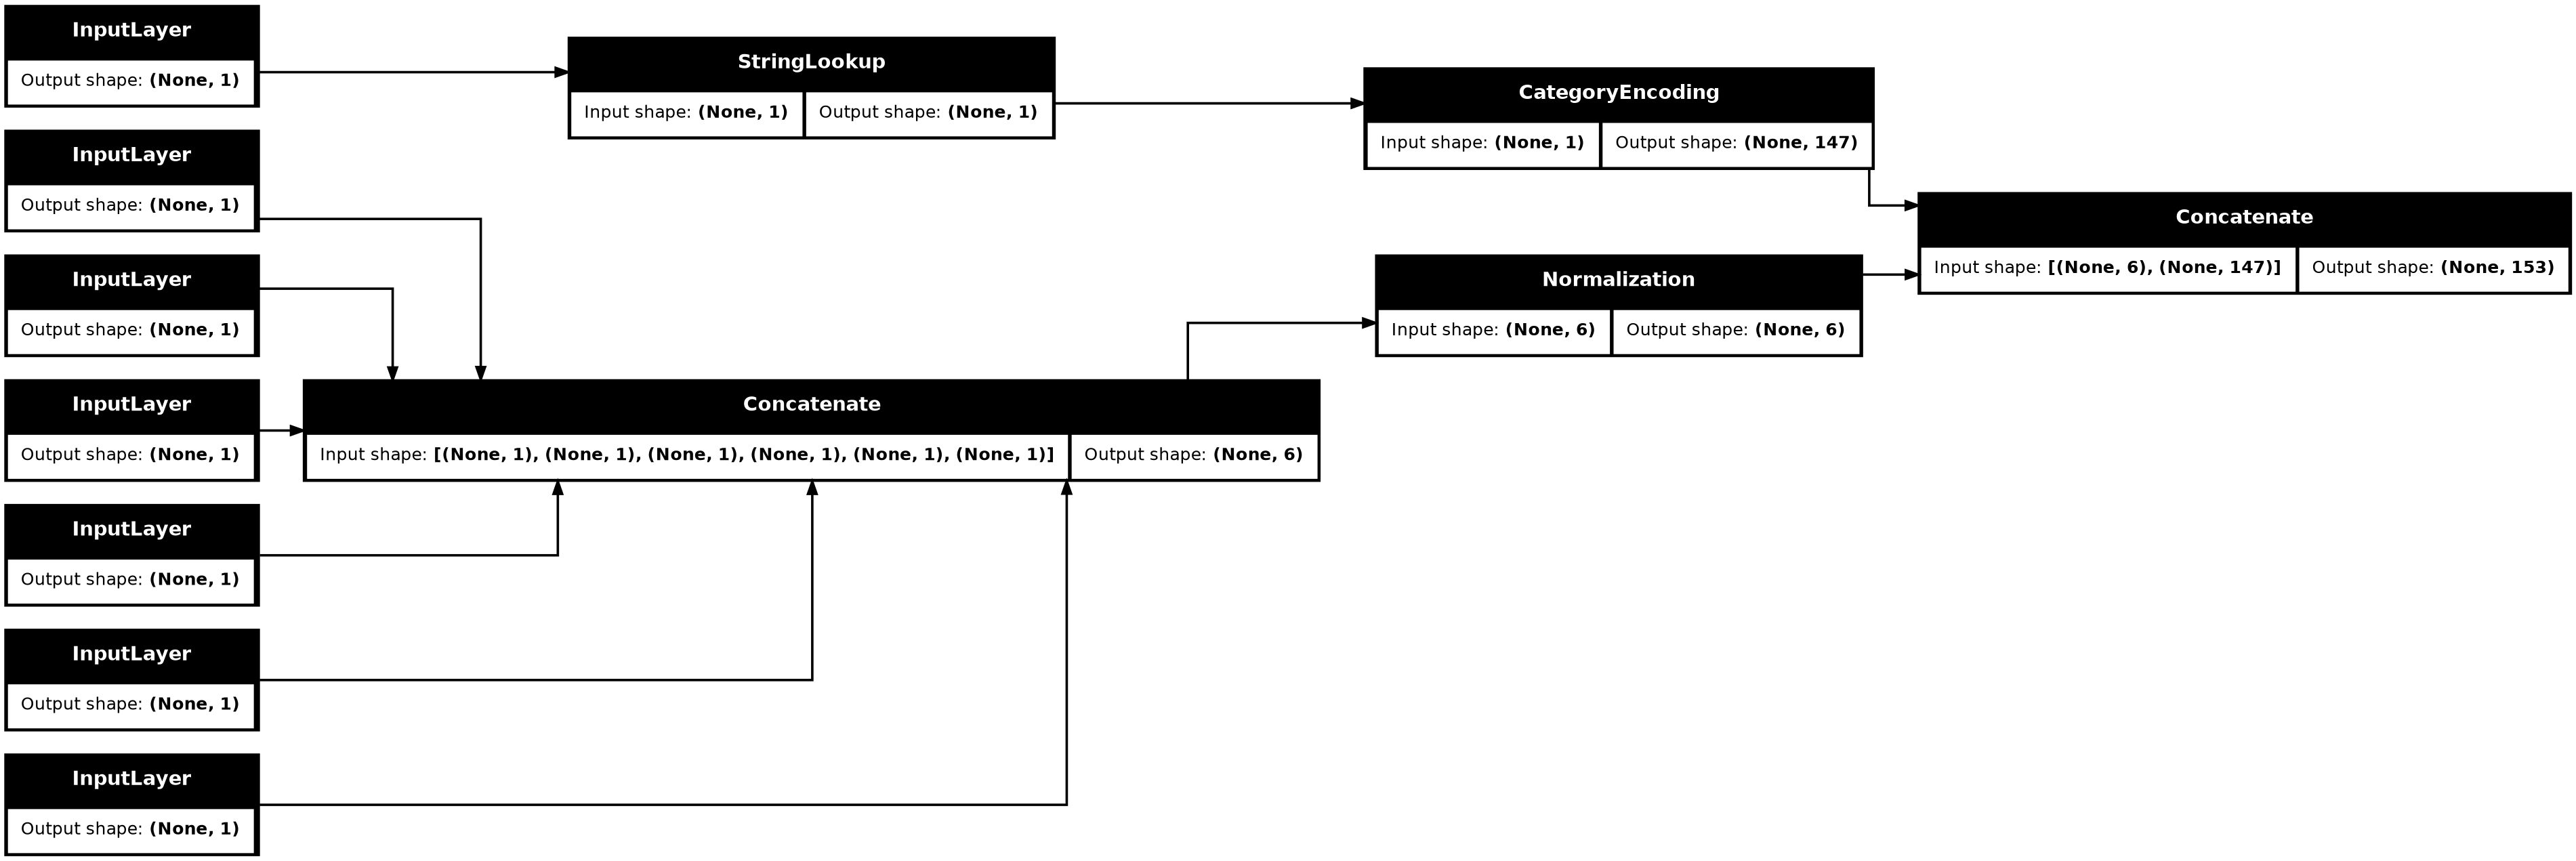

In [ ]:
# visualization of preprocessing layer
preprocessed_inputs_cat = keras.layers.Concatenate()(preprocessed_inputs)
preprocessing_layer = tf.keras.Model(inputs, preprocessed_inputs_cat, name="ProcessData")
tf.keras.utils.plot_model(model=preprocessing_layer, rankdir="LR", dpi=130, show_shapes=True, to_file="processing.png")

In [16]:
# test preprocessing layer

items_features_dict = {name: np.array(value) for name, value in clust_frame.items()}

# grab two samples
two_sample_dict = {name:values[1:3, ] for name, values in items_features_dict.items()}
two_sample_fitted = preprocessing_layer(two_sample_dict)

two_sample_fitted

<tf.Tensor: shape=(2, 153), dtype=float32, numpy=
array([[-0.44319317,  0.80301964, -0.9792361 , -1.7491953 , -1.3605405 ,
        -1.5023069 ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
 

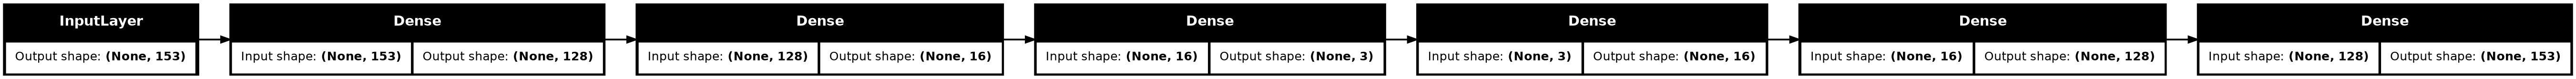

In [ ]:
# dimension reduce via autoencoding layer

# input size grab
full_dim = two_sample_fitted.shape.as_list()[1]

# downsampling/upsampling dimensions
encoding_dim1 = 128
encoding_dim2 = 16
encoding_dim3 = 3 # we will use these 3 dimensions for clustering

# encoding input
encoder_input_data = keras.Input(shape=(full_dim,))

# encoded input representation
encoded_layer1 = keras.layers.Dense(encoding_dim1, activation='relu')(encoder_input_data)
encoded_layer2 = keras.layers.Dense(encoding_dim2, activation='relu')(encoded_layer1)

encoded_layer3 = keras.layers.Dense(encoding_dim3, activation='relu', name="ClusteringLayer")(encoded_layer2)

encoder_model = keras.Model(encoder_input_data, encoded_layer3)

# input reconstruction
decoded_layer3 = keras.layers.Dense(encoding_dim2, activation='relu')(encoded_layer3)
decoded_layer2 = keras.layers.Dense(encoding_dim1, activation='relu')(decoded_layer3)
decoded_layer1 = keras.layers.Dense(full_dim, activation='sigmoid')(decoded_layer2)

# maps input to autoencoder reconstruction
autoencoder_model = keras.Model(encoder_input_data, outputs=decoded_layer1, name="Encoder")

# compile
autoencoder_model.compile(optimizer="RMSprop", loss=tf.keras.losses.MeanSquaredError())
tf.keras.utils.plot_model(model=autoencoder_model, rankdir="LR", dpi=130, show_shapes=True, to_file="autoencoder.png")

In [18]:
len(clust_frame)

2319

In [ ]:
# Train the model

# process the inputs
p_items = preprocessing_layer(items_features_dict)

# split into training and testing (testing arbitrary- just used the dataset ids which are unique to each record, so it doesn't actually do too much)

train_data, test_data, train_labels, test_labels = train_test_split(p_items.numpy(), p_labels, train_size=0.8, random_state=5)

# fit the model using the training data
history = autoencoder_model.fit(train_data, train_data, epochs=1000, batch_size=256, shuffle=True, validation_data=(test_data, test_data))

Epoch 1/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.2708 - val_loss: 0.3494
Epoch 2/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2669 - val_loss: 0.3459
Epoch 3/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2635 - val_loss: 0.3424
Epoch 4/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2597 - val_loss: 0.3383
Epoch 5/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2553 - val_loss: 0.3332
Epoch 6/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2495 - val_loss: 0.3264
Epoch 7/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2412 - val_loss: 0.3154
Epoch 8/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2269 - val_loss: 0.2957
Epoch 9/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2021 - val_loss: 0.2642
Epoch 10/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1654 - val_loss: 0.2226
Epoch 11/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1222 - val_loss: 0.1803
Epoch 12/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0832 - val_l

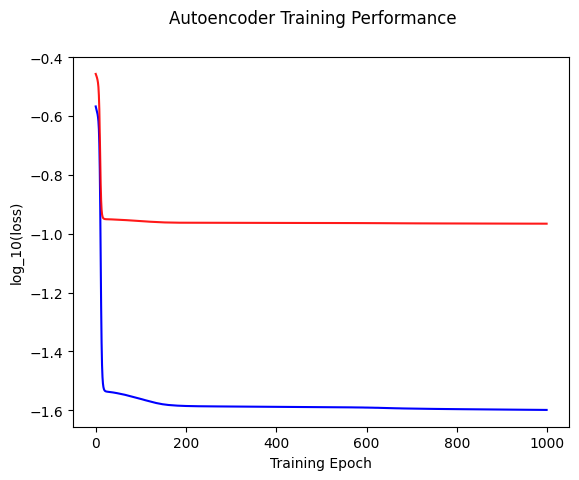

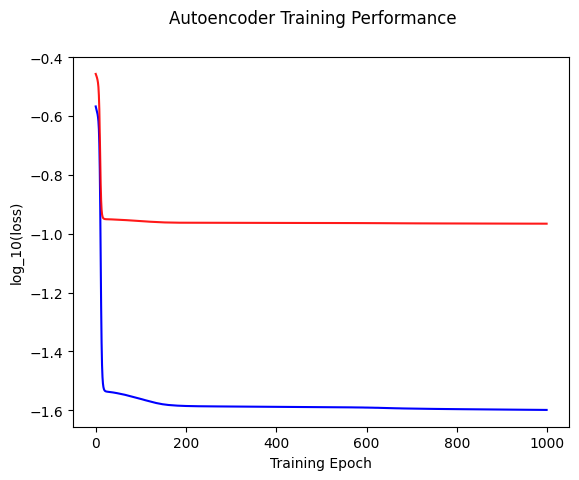

In [ ]:

# Investigate training performance
history_fig, ax1 = plt.subplots()
history_fig.suptitle('Autoencoder Training Performance')
ax1.plot(range(0,1000), np.log10(history.history['loss']), color='blue')
ax1.plot(range(0,1000), np.log10(history.history['val_loss']), color='red', alpha=0.9)
ax1.set(ylabel='log_10(loss)', xlabel='Training Epoch')
history_fig

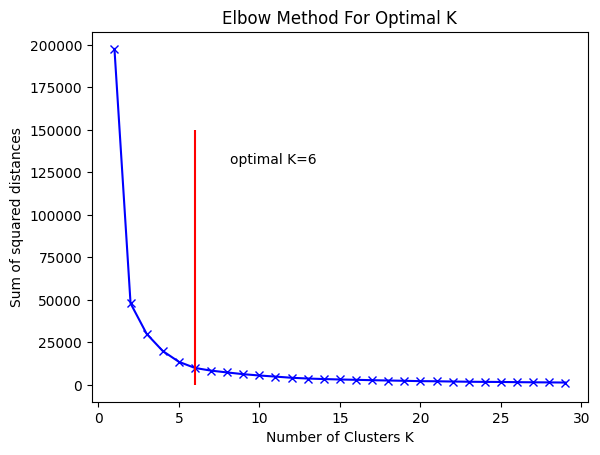

In [ ]:
# Cluster

encoded_items = encoder_model(p_items)

# choose number of clusters K via elbow method
Sum_of_squared_distances = []
K = range(1,30)
for k in K:
    km = KMeans(init='k-means++', n_clusters=k, n_init=10)
    km.fit(encoded_items)
    Sum_of_squared_distances.append(km.inertia_)

plt.plot(K, Sum_of_squared_distances, 'bx-')
plt.vlines(ymin=0, ymax=150000, x=6, colors='red')
plt.text(x=8.2, y=130000, s="optimal K=6")
plt.xlabel('Number of Clusters K')
plt.ylabel('Sum of squared distances')
plt.title('Elbow Method For Optimal K')
plt.show()

In [ ]:
kmeans = KMeans(init='k-means++', n_clusters=6, n_init=10)
kmeans.fit(encoded_items)
P = kmeans.predict(encoded_items)

In [23]:
clust_frame['cluster'] = P
clust_frame.head()

,geo_meanElev,geo_meanLat,geo_meanLon,paleoData_sensorSpecies,b1_values,b2_values,b3_values,cluster
0,2700.0,32.500000,-110.800003,PSME,0.694042,0.636517,0.664917,2
1,800.0,60.200001,-138.500000,PCGL,0.271071,0.350350,0.392383,3
2,800.0,60.200001,-138.500000,PCGL,0.970786,1.007933,1.046033,3
3,1200.0,54.900002,-127.300003,PCGL,0.558917,0.842467,0.790900,1
4,213.0,67.199997,-115.900002,PCSP,0.221722,0.180050,0.103383,3


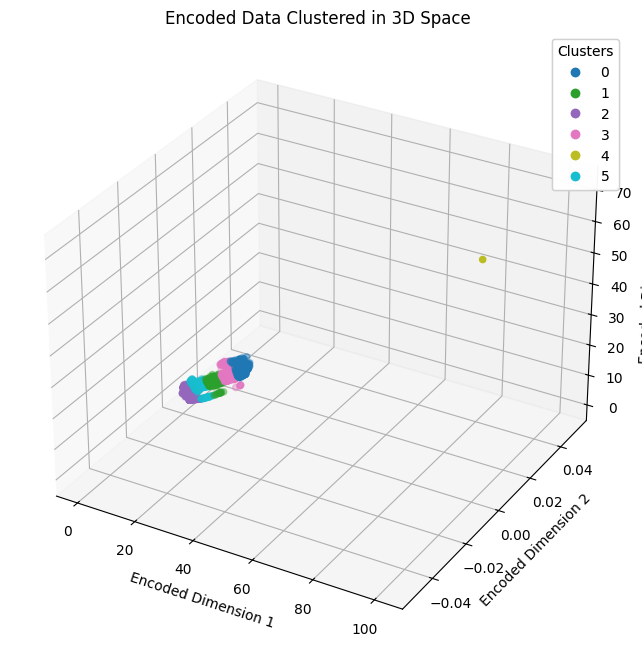

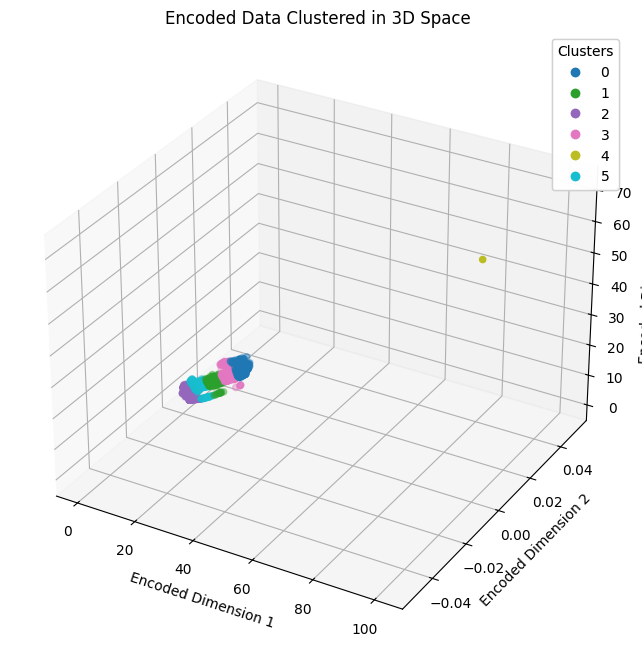

In [ ]:
# plot encoded data in 3d space 
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(encoded_items[:, 0], encoded_items[:, 1], encoded_items[:, 2], c=P, cmap='tab10')
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)
ax.set_title('Encoded Data Clustered in 3D Space')
ax.set_xlabel('Encoded Dimension 1')
ax.set_ylabel('Encoded Dimension 2')
ax.set_zlabel('Encoded Dimension 3')
fig